In [1]:
%run ../run_config_project.py
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data


You are working with      IGVF BlueSTARR
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references



In [15]:
# --- CONFIG: set these for your env ---
FP_LODS = "/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/JASPAR2024_CORE_vertebrates_non-redundant.lods.npz"
FP_PMAP = "/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/JASPAR2024_CORE_vertebrates_non-redundant.pmap.npz"  # optional (for Tbind & weights)
MOTIF_NAME = "MA0099.4 FOS::JUN"  # pick any motif in your NPZ

# --- imports ---
import numpy as np
import matplotlib.pyplot as plt
from motifdelta.scan import scan_motif_both_strands

# --- 1) Build 71-bp centered variant: ref=C, alt=T ---
L = 71
center = L // 2  # 35
seq_ref = "C" * L
seq_alt = seq_ref[:center] + "G" + seq_ref[center+1:]

# --- 2) Load motif log-odds (and optional PMAP with Tbind) ---
obj_lods = np.load(FP_LODS, allow_pickle=True)
dct_lods = obj_lods["lods"].item()
arr_lod_Wx4 = dct_lods[MOTIF_NAME]  # shape (W,4)

try:
    obj_pmap = np.load(FP_PMAP, allow_pickle=True)
    dct_pmap = obj_pmap["dct_results"].item()
    Tbind = float(dct_pmap[MOTIF_NAME]["num_Tbind"])
except Exception:
    dct_pmap = None
    Tbind = None

In [19]:
# --- 3) Scan both alleles, both strands ---
f_ref, r_ref = scan_motif_both_strands(seq_ref, arr_lod_Wx4)
f_alt, r_alt = scan_motif_both_strands(seq_alt, arr_lod_Wx4)

# NaN-pad tail to fixed length (71) so positions align visually
def pad_to_len(x, L=71):
    if len(x) < L:
        x = np.pad(x, (0, L - len(x)), constant_values=np.nan)
    return x

f_ref, r_ref = pad_to_len(f_ref, L), pad_to_len(r_ref, L)
f_alt, r_alt = pad_to_len(f_alt, L), pad_to_len(r_alt, L)

# --- 4) Compute Δ = alt - ref (per position) ---
d_f = f_alt - f_ref  # forward
d_r = r_alt - r_ref  # reverse

# --- 5) Optional: score-space weight using Tbind (if available) ---
def logistic_weight(max_score, T, k=1.0):
    z = -(max_score - T) / k
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(z))

if Tbind is not None:
    # stack and compute per-position max safely (ignore all-NaN slices)
    arr_stack_f = np.vstack([f_alt, f_ref])
    arr_stack_r = np.vstack([r_alt, r_ref])

    # Identify positions where both alleles are NaN
    mask_valid_f = np.any(np.isfinite(arr_stack_f), axis=0)
    mask_valid_r = np.any(np.isfinite(arr_stack_r), axis=0)

    # Use np.nanmax only on valid columns
    m_f = np.full(L, np.nan)
    m_r = np.full(L, np.nan)
    if np.any(mask_valid_f):
        m_f[mask_valid_f] = np.nanmax(arr_stack_f[:, mask_valid_f], axis=0)
    if np.any(mask_valid_r):
        m_r[mask_valid_r] = np.nanmax(arr_stack_r[:, mask_valid_r], axis=0)

    # logistic weights only on valid positions
    w_f = np.full(L, np.nan)
    w_r = np.full(L, np.nan)
    w_f[mask_valid_f] = logistic_weight(m_f[mask_valid_f], Tbind, k=1.0)
    w_r[mask_valid_r] = logistic_weight(m_r[mask_valid_r], Tbind, k=1.0)

    dw_f = w_f * d_f
    dw_r = w_r * d_r
else:
    w_f = w_r = dw_f = dw_r = None

In [20]:
# --- 6) Plot Δ (and Δw if available) ---
x = np.arange(L)
#x = np.arange(L) - center

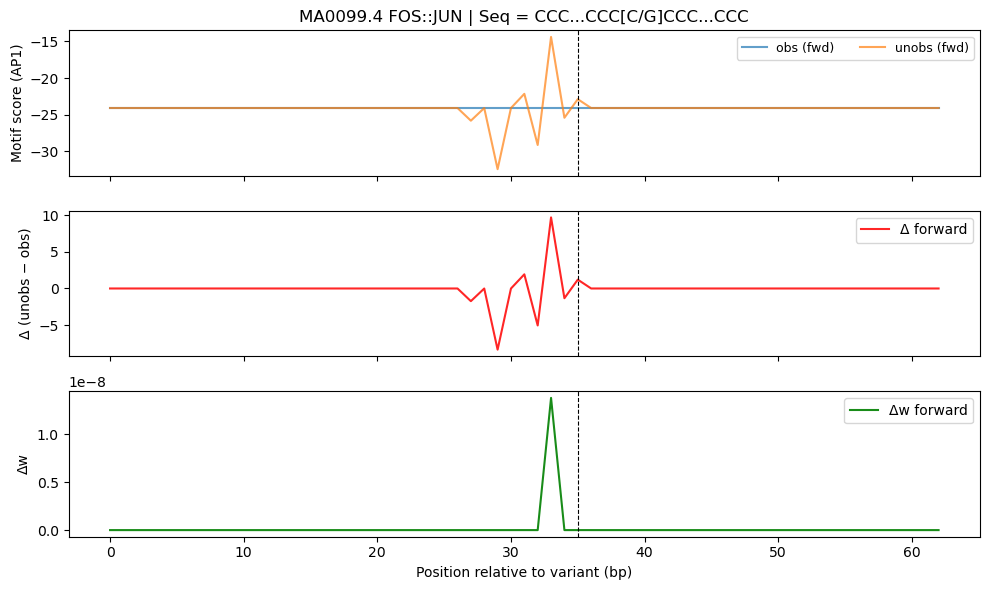

In [27]:
fig, axes = plt.subplots(2 if Tbind is None else 3, 1, figsize=(10, 6), sharex=True)

ax = axes[0]
ax.plot(x, f_ref, alpha=0.7, label="obs (fwd)")
ax.plot(x, f_alt, alpha=0.7, label="unobs (fwd)")
#ax.plot(x, r_ref, lw=0.8, alpha=0.7, label="ref (rev)")
#ax.plot(x, r_alt, lw=0.8, alpha=0.7, label="alt (rev)")
#ax.axvline(0, color="k", ls="--", lw=0.8)
ax.axvline(35, color="k", ls="--", lw=0.8)
ax.set_ylabel("Motif score (AP1)")
ax.legend(ncol=2, fontsize=9)
ax.set_title(f"{MOTIF_NAME} | Seq = CCC...CCC[C/G]CCC...CCC")

ax = axes[1]
ax.plot(x, d_f, label="Δ forward", alpha=0.85, c = "red")
#ax.plot(x, d_r, label="Δ reverse", alpha=0.85)
#ax.axvline(0, color="k", ls="--", lw=0.8)
ax.axvline(35, color="k", ls="--", lw=0.8)
ax.set_ylabel("Δ (unobs − obs)")
ax.legend()

if Tbind is not None:
    ax = axes[2]
    ax.plot(x, dw_f, label="Δw forward", alpha=0.9, c = "green")
    #ax.plot(x, dw_r, label="Δw reverse", alpha=0.9)
    #ax.axhline(0, color="k", lw=0.6)
    #ax.axvline(0, color="k", ls="--", lw=0.8)
    ax.axvline(35, color="k", ls="--", lw=0.8)
    ax.set_ylabel("Δw")
    ax.set_xlabel("Position relative to variant (bp)")
    ax.legend()
else:
    axes[1].set_xlabel("Position relative to variant (bp)")

plt.tight_layout()
plt.show()